# Complete Exploratory Data Analysis

## Georgia Tech MSA Spring 2026 Practicum

This Analysis file reflects tactical play style clustering and temporal analysis after the refined feature set is established in EDA.ipynb.

In [1]:
# Import libraries

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.cm as cm
from sklearn.decomposition import PCA
import random

from utility_functions import load_events, load_matches, extract_tactical_dna, prepare_style_matrix, plot_tactical_radar, plot_tactical_pca

# Set seed for reproducibility
np.random.seed(21)  
random.seed(21)

In [2]:
# Load data
events = load_events()
matches = load_matches()

cluster_features = [
    "completion_rate", 
    "avg_pass_verticaldistance", 
    "avg_carry_distance", 
    "risky_pass_rate",
    "dribble_success_rate",
    "avg_shot_distance", 
    "through_ball_shot_rate", 
    "big_chance_shot_rate"
]

# Extract tactical DNA and prepare style matrix
match_style_stats = extract_tactical_dna(events)
style_matrix_raw, style_matrix_scaled, style_values_scaled = prepare_style_matrix(match_style_stats, cluster_features)

## Clustering

The next phase of this analysis will take the refined feature set to cluster match performance into distinct tactical styles of play. 

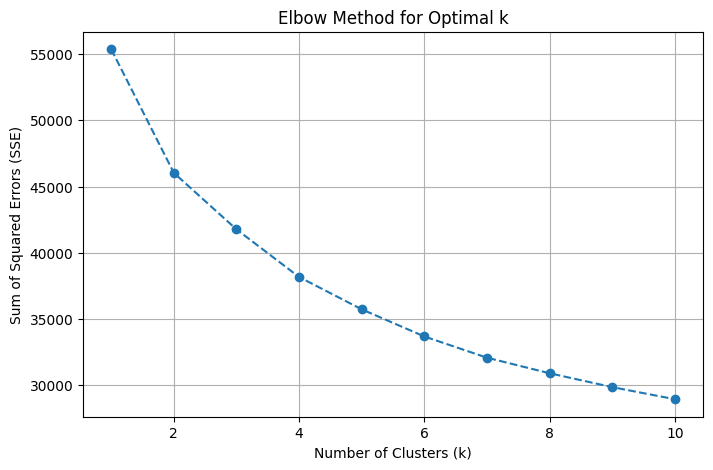

In [3]:
# Calculate Sum of Squared Errors (SSE) for different K values to determine optimal number of clusters
sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=21, n_init=10)
    kmeans.fit(style_values_scaled)
    sse.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

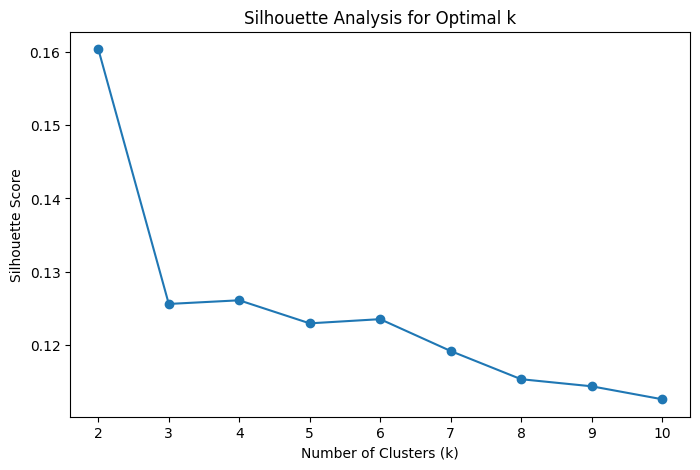

In [4]:
# Calculate Silhouette Scores for different K values to determine optimal number of clusters
sil_scores = []
k_range = range(2, 11) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=21, n_init=10)
    labels = kmeans.fit_predict(style_values_scaled)
    score = silhouette_score(style_values_scaled, labels)
    sil_scores.append(score)

# Plotting Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.show()

 The elbow method and silhouette score plot above are used to identify an optimal number of clusters. 
 
 The silhouette score is highest for 2 clusters and slightly lower for 3-6 clusters. The elbow plot shows an elbow at 2 clusters and an approximate elbow at 4 clusters. These results suggest that 4 clusters may capture more nuanced tactical differences without over-simplifying into just 2 groups. While not very large, the silhouette score is above 0, indicating that the clusters are reasonably well-defined and not just random groupings. 
 
 This balance between the Elbow method and Silhouette analysis supports the choice of k=4 for the final clustering to identify distinct tactical archetypes among teams.

In [5]:
# Fit the final model 
optimal_k = 4 
kmeans_final = KMeans(n_clusters=optimal_k, random_state=21, n_init=10)
cluster_labels = kmeans_final.fit_predict(style_values_scaled)

# Add cluster labels to the Style Matrix
style_matrix_raw = style_matrix_raw.with_columns(
    pl.Series(name="cluster", values=cluster_labels)
)

print(f"Successfully clustered match performances into {optimal_k} tactical archetypes.")

Successfully clustered match performances into 4 tactical archetypes.


In [6]:
# Calculate the mean of each feature per cluster to define "Styles"
cluster_profiles = (
    style_matrix_raw.group_by("cluster")
    .agg([pl.col(feature).mean() for feature in cluster_features])
    .sort("cluster")
)

# Convert to pandas for better display formatting
final_table = cluster_profiles.to_pandas()

# Set the display precision to show 2 decimal places
with pd.option_context('display.precision', 2):
    print("Tactical Cluster Profiles (Averages):")
    display(final_table)

Tactical Cluster Profiles (Averages):


,cluster,completion_rate,avg_pass_verticaldistance,avg_carry_distance,risky_pass_rate,dribble_success_rate,avg_shot_distance,through_ball_shot_rate,big_chance_shot_rate
0,0,75.19,8.61,3.27,7.13,57.37,18.78,2.71,6.89
1,1,65.23,12.65,2.69,4.97,53.17,20.39,3.03,6.00
2,2,80.37,6.47,2.44,4.62,56.11,20.57,1.95,3.66
3,3,81.34,6.18,2.38,5.06,59.70,17.02,10.00,18.31


##### Tactical Cluster Descriptions

Cluster 0: Vertical Counter-Attackers
- Tactical Identity: Transition-heavy teams that rely on individual initiative and driving forward with the ball to catch opponents out of position.

- Key Metrics: Highest avg_carry_distance (3.27 yards), highest risky_pass_rate (7.13%), and a strong dribble_success_rate (57.37%).

- Narrative: These teams use dynamic ball carriers to advance upfield and break defensive lines. They aggresively use risky passes to exploit space during defensive transitions. 

Cluster 1: High-Risk Chaos Merchants
- Tactical Identity: "Route One" specialists who prioritize immediate territory and vertical progression over sustained ball retention.

- Key Metrics: Highest avg_pass_verticaldistance (12.65 yards), the lowest completion_rate (65.23%), and the lowest dribble success rate (53.17%).

- Narrative: These teams move the ball forward as fast as possible. The lower precision is a deliberate tactical trade-off; by constantly playing direct balls, they bypass the midfield and create chaotic moments in the final third, aiming to overwhelm opponents through sheer verticality and aggression.

Cluster 2: Tiki-Taka Safe Possession
- Tactical Identity: Technical teams focused on total control and defensive security through ball retention, but who often struggle to penetrate into the box for scoring opportunities. 

- Key Metrics: High completion_rate (80.37%) but a low avg_pass_verticaldistance (6.47 yards) and lowest big_chance_shot_rate (3.66%).

- Narrative: These teams rely on safe and horizontal possession to eventually break down teams. While they are incredibly difficult to dispossess, their play lacks vertical bite. This is evidenced by the highest avg_shot_distance in the dataset (20.57 yards), suggesting they often settle for long-range shots when they cannot break through a defense.

Cluster 3: Efficiency Specialists
- Tactical Identity: The highest-performing attacking archetype. These teams combine technical precision with elite penetration to create the best chances in the dataset.

- Key Metrics: Highest completion_rate (81.34%), highest through_ball_shot_rate (10.00%), and a dominant big_chance_shot_rate (18.31%). They also record the closest avg_shot_distance (17.02 yards).

- Narrative: These teams take advantage of possession and use elite passing to unlock devenses. By prioritizing through-balls and high-quality opportunities inside the box, they demonstrate a "quality over quantity" philosophy that maximizes scoring potential.

The clustered play style profiles are visualized in a radar chart below. 

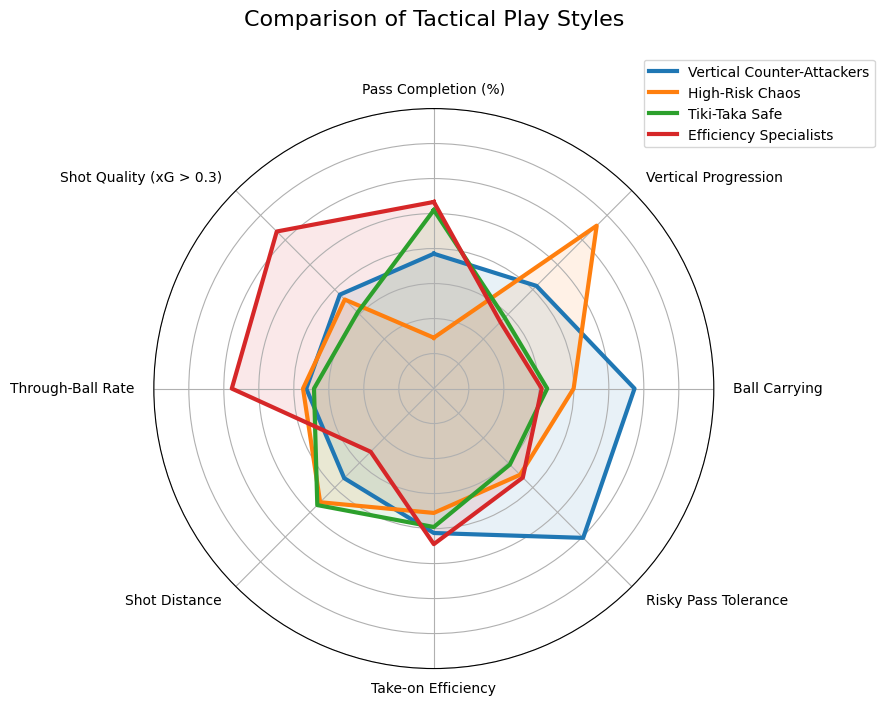

In [7]:
# Recalculate the cluster profiles using scaled data
# Use scaled means so the radar axes are consistent
cluster_profiles_scaled = (
    pd.DataFrame(style_values_scaled, columns=cluster_features)
    .assign(cluster=cluster_labels)
    .groupby("cluster")
    .mean()
    .reset_index()
)

# Mapping raw feature names to more descriptive labels
label_map = {
    "completion_rate": "Pass Completion (%)",
    "avg_pass_verticaldistance": "Vertical Progression",
    "risky_pass_rate": "Risky Pass Tolerance",
    "avg_carry_distance": "Ball Carrying",
    "dribble_success_rate": "Take-on Efficiency",
    "avg_shot_distance": "Shot Distance",
    "through_ball_shot_rate": "Through-Ball Rate",
    "big_chance_shot_rate": "Shot Quality (xG > 0.3)"
}

# Generate the list of clean labels in the correct order
clean_labels = [label_map[feat] for feat in cluster_features]

# Define custom cluster names based on the profiles we observed
my_cluster_names = {
    0: "Vertical Counter-Attackers",
    1: "High-Risk Chaos",
    2: "Tiki-Taka Safe",
    3: "Efficiency Specialists"
}

# Call the function to visualize all 4 play styles overlaid
plot_tactical_radar(
    data=cluster_profiles_scaled, 
    features=cluster_features, 
    clean_labels=clean_labels, 
    cluster_map=my_cluster_names,
    title="Comparison of Tactical Play Styles"
)


The clusters can be visualized in 2 dimensions using Principal Component Analysis (PCA) to evaluate cluster separation and the primary drivers of cluster separation. 

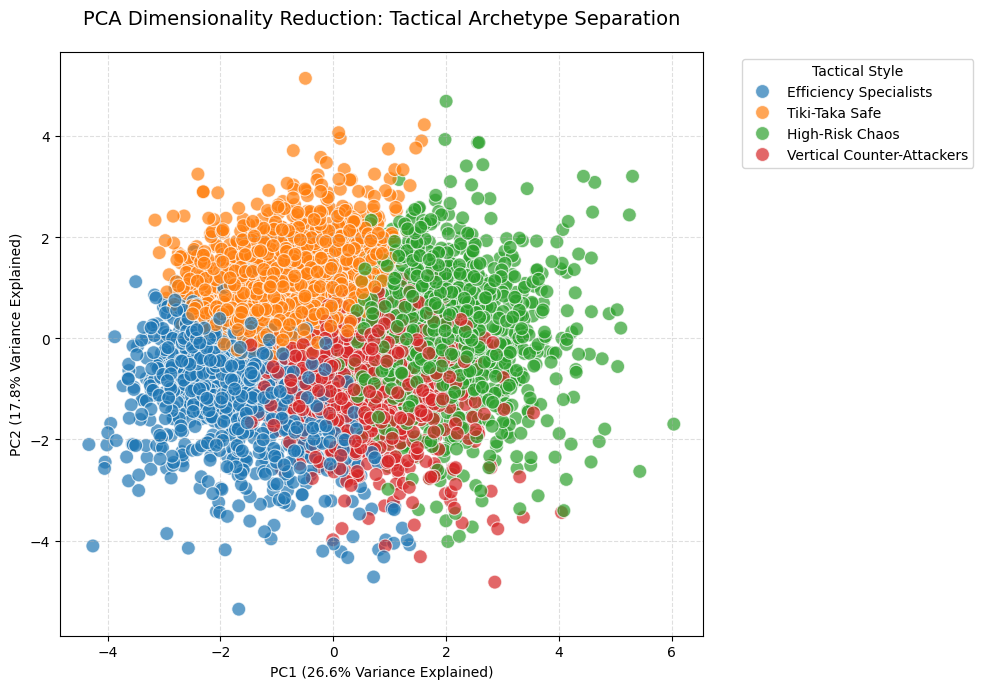

In [8]:
pca_model = plot_tactical_pca(style_matrix_raw, cluster_features, cluster_map=my_cluster_names)

In [9]:
# Show which features drive the axes
loadings = pd.DataFrame(
    pca_model.components_.T, 
    columns=['PC1', 'PC2'], 
    index=cluster_features
)
print("Top 3 Drivers for PC1:")
display(loadings['PC1'].sort_values(ascending=False).head(3))

print("\nTop 3 Drivers for PC2:")
display(loadings['PC2'].sort_values(ascending=False).head(3))

Top 3 Drivers for PC1:


avg_pass_verticaldistance    0.635019
avg_carry_distance           0.257486
avg_shot_distance            0.202863
Name: PC1, dtype: float64


Top 3 Drivers for PC2:


avg_shot_distance       0.581818
completion_rate         0.124243
dribble_success_rate   -0.047889
Name: PC2, dtype: float64

To validate the identified tactical archetypes, a Principal Component Analysis (PCA) was performed, projecting the 8-dimensional feature set into a 2D plane. This analysis captures 44.4% of the total tactical variance (PC1: 26.6%, PC2: 17.8%).

Interpreting the Principal Components
- PC1: The "Directness & Verticality" Axis (26.6%):
This component is heavily driven by avg_pass_verticaldistance (0.64) and avg_carry_distance (0.26). It represents a team's intent to move the ball forward quickly. High values on this axis correspond to direct, transition-heavy styles, while low values represent horizontal, patient buildup.

- PC2: The "Shot Proximity & Penetration" Axis (17.8%):
This component is dominated by avg_shot_distance (0.58). Interestingly, completion_rate (0.12) also loads positively here. This suggests that PC2 identifies the "Perimeter vs. Interior" nature of an attack. High PC2 scores represent teams that maintain possession but struggle to penetrate the box, resulting in a higher volume of long-distance shots.

The distribution of teams across these components confirms our tactical archetypes:

- Cluster 1 (High-Risk Chaos) & Cluster 0 (Vertical Counter-Attackers): These load high on PC1, confirming their identity as the game's most vertical and direct teams. 

- Cluster 2 (Tiki-Taka Safe): These load high on PC2 and low on PC1. This mathematically mirrors the "Sterile Possession" profile: they keep the ball well (high completion) but take shots from the furthest average distance, failing to penetrate deep into the "danger zone."

- Cluster 3 (Efficiency Specialists): These load low on PC2, representing the most "Interior" attackers. By minimizing shot distance, they maximize xG. Their central position on PC1 suggests they are "Tactical Generalists," capable of blending both patient and direct play to create high-quality chances.

Conclusion
- The PCA results confirm that the identified clusters are not merely statistical artifacts but represent distinct strategic profiles, where the primary tension between vertical directness (PC1) and penetrative efficiency (PC2) defines the competitive landscape of the sport.

## Play Style Success Analysis

The final phase of the analysis will examine the win rate of each play style. Which play styles are most successful overall? Which play styles are particularly strong or weak against others? How has play style success evolved over the years?

In [10]:
# First create a match results table that aggregates goals scored by each team in each match, 
# and then calculates the outcome (win/loss/draw) and points earned for each team in each match.

# Aggregate goals from events
goals_per_match = (
    events.filter(pl.col("shot_outcome") == "Goal")
    .group_by(["match_id", "team"])
    .agg(pl.count("id").alias("team_goals"))
)

# Get the master list of all teams in all matches (to capture teams that scored 0 goals)
all_participating_teams = events.select(["match_id", "team"]).unique()

# Create a single-row-per-team results table
results_base = all_participating_teams.join(
    goals_per_match, on=["match_id", "team"], how="left"
).with_columns(pl.col("team_goals").fill_null(0))

# Self-join to bring in the opponent's score for each match
match_results = (
    results_base.join(
        results_base.select([
            pl.col("match_id"),
            pl.col("team").alias("opponent"),
            pl.col("team_goals").alias("opponent_goals")
        ]),
        on="match_id",
        how="inner"
    )
    .filter(pl.col("team") != pl.col("opponent")) # Remove rows joining team to itself
)

# Calculate Outcomes and Points
match_results = match_results.with_columns([
    pl.when(pl.col("team_goals") > pl.col("opponent_goals")).then(pl.lit("Win"))
    .when(pl.col("team_goals") < pl.col("opponent_goals")).then(pl.lit("Loss"))
    .otherwise(pl.lit("Draw"))
    .alias("outcome"),
    
    pl.when(pl.col("team_goals") > pl.col("opponent_goals")).then(3)
    .when(pl.col("team_goals") == pl.col("opponent_goals")).then(1)
    .otherwise(0)
    .alias("points")
])

display(match_results.head())

match_id,team,team_goals,opponent,opponent_goals,outcome,points
i32,str,u32,str,u32,str,i32
69162,"""Barcelona""",1,"""Real Betis""",1,"""Draw""",1
3901832,"""Colombia Women's""",1,"""Jamaica Women's""",0,"""Win""",3
3890421,"""FSV Mainz 05""",1,"""Borussia Mönchengladbach""",0,"""Win""",3
3879654,"""Chievo""",1,"""Atalanta""",0,"""Win""",3
3890513,"""FSV Mainz 05""",1,"""Wolfsburg""",1,"""Draw""",1


In [11]:
# Create a mapping of match_id + team -> cluster
cluster_lookup = style_matrix_raw.select(["match_id", "team", "cluster"])

# Join cluster IDs for the primary team
match_success = match_results.join(
    cluster_lookup, on=["match_id", "team"], how="inner"
)

# Join cluster IDs for the opponent team (renaming for clarity)
match_success = match_success.join(
    cluster_lookup.rename({"team": "opponent", "cluster": "opponent_cluster"}),
    on=["match_id", "opponent"],
    how="inner"
)

In [12]:
# Calculate overall performance metrics by cluster

overall_stats = (
    match_success.group_by("cluster")
    .agg([
        (pl.col("outcome") == "Win").mean().alias("Win %"),
        pl.col("points").mean().alias("Avg PPG"),
        pl.count("match_id").alias("Sample Size")
    ])
    .with_columns(pl.col("cluster").map_elements(lambda x: my_cluster_names.get(x, x)).alias("Style"))
    .sort("Avg PPG", descending=True)
)

print("Overall Performance by Tactical Archetype:")
display(overall_stats.to_pandas().round(3))

Overall Performance by Tactical Archetype:


,cluster,Win %,Avg PPG,Sample Size,Style
0,3,0.681,2.171,1322,Efficiency Specialists
1,0,0.342,1.290,1711,Vertical Counter-Attackers
2,2,0.327,1.207,2296,Tiki-Taka Safe
3,1,0.272,1.093,1585,High-Risk Chaos


The Overall Performance table shows a massive gap between the most and least effective styles:

Cluster 3 (Efficiency Specialists) is dominant in PPG with 2.171 Points Per Game and a 68.1% Win Rate.

Cluster 2 (Tiki-Taka Safe) is the least effective with only 1.093 PPG and a 27.2% Win Rate.

Key Insight: This mathematically proves that possession without penetration is failing. The Efficiency Specialists (Cluster 3) and Tiki-Taka Safe (Cluster 2) both keep the ball (81.3% vs 80.4% completion), but Cluster 0 wins 2.5x more often because they penetrate the box.

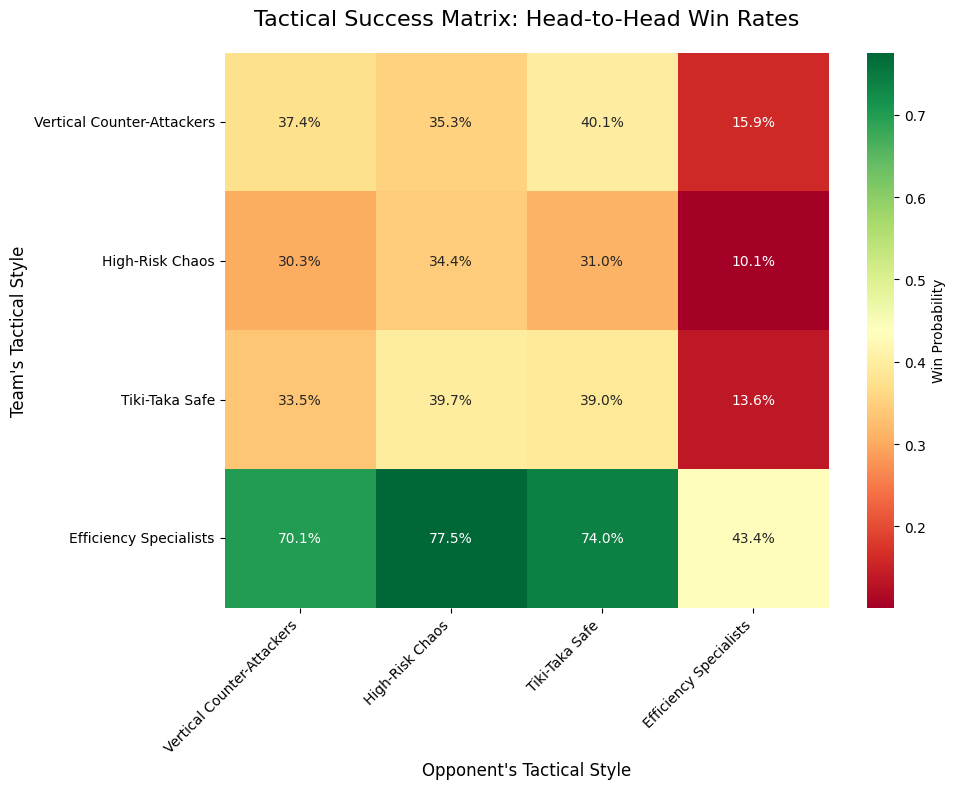

In [13]:
# Calculate win rate for every cluster pairing
h2h_data = (
    match_success.group_by(["cluster", "opponent_cluster"])
    .agg((pl.col("outcome") == "Win").mean().alias("win_rate"))
    .to_pandas()
)

# 2. Pivot the data for the heatmap
h2h_pivot = h2h_data.pivot(index="cluster", columns="opponent_cluster", values="win_rate")

# 3. Rename indices/columns using descriptive names
h2h_pivot.index = [my_cluster_names.get(i) for i in h2h_pivot.index]
h2h_pivot.columns = [my_cluster_names.get(c) for c in h2h_pivot.columns]

# 4. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(h2h_pivot, annot=True, cmap="RdYlGn", fmt=".1%", cbar_kws={'label': 'Win Probability'})

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')

plt.title("Tactical Success Matrix: Head-to-Head Win Rates", size=16, pad=20)
plt.xlabel("Opponent's Tactical Style", size=12)
plt.ylabel("Team's Tactical Style", size=12)
plt.tight_layout()
plt.show()

The Head-to-Head matrix reveals some interesting competitive dynamics:

- While the Efficiency Specialists maintain a dominant >70% win rate against disparate styles, their effectiveness drops significantly (to 43%) in against similar playstyles. This suggests that their system relies on a technical superiority that is neutralized when facing an opponent with an identical tactical style, turning the match into a low-variance stalemate or a tactical chess match.

- The Vertical Counter-Attackers find their highest level of success when facing the Tiki-Taka archetype. This highlights a classic tactical exploitation: the patient, high-line possession of Tiki-Taka provides the exact long-field transition opportunities that Vertical Counter-Attackers are engineered to exploit.

Conclusion: 

- The results demonstrate that Efficiency Specialists (Cluster 3) represent the most successful tactical archetype in the modern era, maintaining a win rate above 70% against most opposing styles. However, the significant performance degradation observed in inter-cluster matchups (44% win rate) suggests that this dominance is dependent on stylistic contrast. Furthermore, the specialized success of Vertical Counter-Attackers (Cluster 0) against Tiki-Taka (Cluster 2) highlights that specific archetypes remain highly effective at neutralizing possession-heavy systems. Ultimately, the analysis indicates that the tactical landscape is a balanced ecosystem where the "Efficiency" model offers the highest overall success rate, but remains susceptible to specific stylistic counters and internal symmetry.

In [14]:
# Extract year from match_date 
matches = matches.with_columns(
    pl.col("match_date").str.to_date().dt.year().alias("year")
)

# Join 'year' to the match outcomes and cluster assignments
temporal_success = match_success.join(
    matches.select(["match_id", "year"]),
    on="match_id",
    how="left"
)

# Attach 'year' to the match outcomes and cluster assignments
temporal_success = match_success.join(
    matches.select(["match_id", "year"]),
    on="match_id",
    how="left"
)

In [15]:
# Calculate the number of matches per cluster per year to understand data availability and justify the study period

# Pivot the data to show match counts per cluster per year
full_sample_sizes = (
    temporal_success.group_by(["year", "cluster"])
    .agg(pl.count("match_id").alias("match_count"))
    .pivot(values="match_count", index="year", on="cluster")
    .sort("year")
    .fill_null(0)
)

# Apply descriptive names to columns
name_map = {str(k): v for k, v in my_cluster_names.items()}
full_sample_sizes = full_sample_sizes.rename({
    c: name_map[c] for c in full_sample_sizes.columns if c in name_map
})

# Calculate annual totals to justify the study period
style_cols = [c for c in full_sample_sizes.columns if c != "year"]
full_sample_sizes = full_sample_sizes.with_columns(
    pl.sum_horizontal(style_cols).alias("Annual_Total")
)

# Highlight years with > 200 matches
def highlight_threshold(s):
    return ['background-color: #d1e7dd' if v >= 200 else '' for v in s]

print("Table: Annual Data Volume (Green indicates years with N > 200)")
display(full_sample_sizes.to_pandas().set_index("year")
        .style.apply(highlight_threshold, subset=['Annual_Total']))

Table: Annual Data Volume (Green indicates years with N > 200)


,Efficiency Specialists,High-Risk Chaos,Vertical Counter-Attackers,Tiki-Taka Safe,Annual_Total
year,,,,,
1958,0,0,4,0,4
1962,0,0,2,0,2
1970,0,0,8,4,12
1971,0,1,1,0,2
1972,0,1,1,0,2
1973,0,0,2,0,2
1974,0,3,10,1,14
1977,0,0,2,0,2
1978,0,2,0,0,2


Based on the data availability, we will focus our temporal analysis on the period from 2015 to 2022, which has a consistent volume of matches across all clusters.

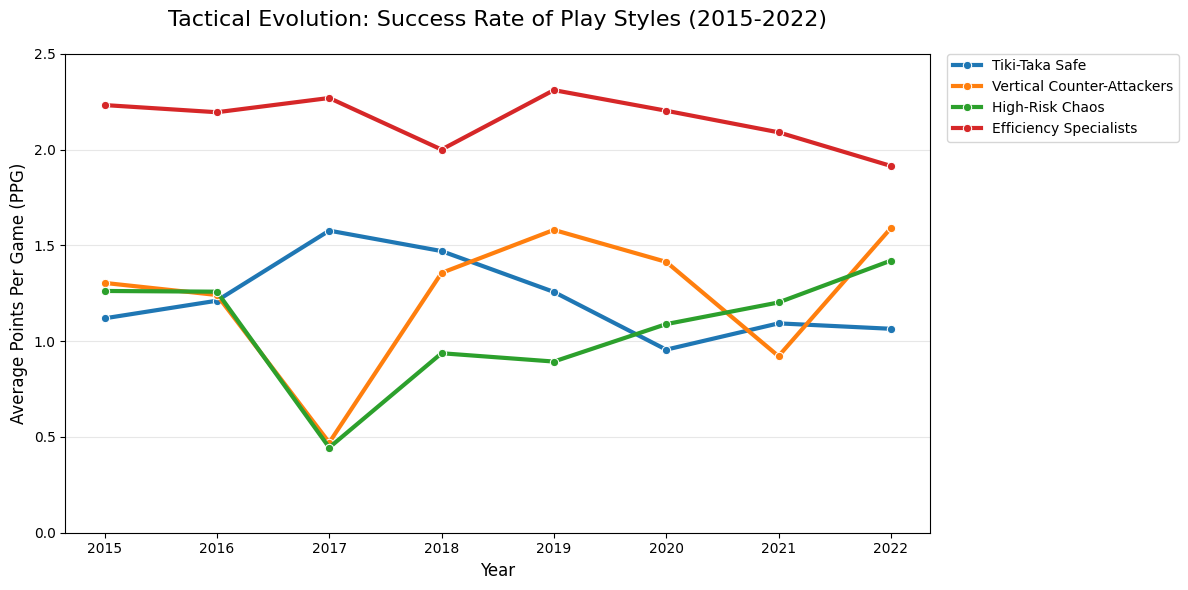

In [16]:
# Filter for the high-density period identified in the table above
study_period_df = temporal_success.filter((pl.col("year") >= 2015) & (pl.col("year") <= 2022))

# Calculate Average Points Per Game (PPG)
yearly_ppg = (
    study_period_df.group_by(["year", "cluster"])
    .agg(pl.col("points").mean().alias("avg_ppg"))
    .sort("year")
    .to_pandas()
)
yearly_ppg['Tactical Style'] = yearly_ppg['cluster'].map(my_cluster_names)

# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=yearly_ppg, 
    x="year", y="avg_ppg", 
    hue="Tactical Style", 
    marker="o", linewidth=3,
    palette="tab10"
)

plt.title("Tactical Evolution: Success Rate of Play Styles (2015-2022)", size=16, pad=20)
plt.ylabel("Average Points Per Game (PPG)", size=12)
plt.xlabel("Year", size=12)
plt.xticks(range(2015, 2023))
plt.ylim(0, 2.5)
plt.grid(axis='y', alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

##### Key Observations

- Volatility of Vertical Counter-Attackers (Cluster 0): This style maintains a competitive baseline between 1.0 and 1.5 PPG. Its performance peaked between 2018 and 2020 before a sharp dip in 2021; however, a strong recovery in 2022 confirms the enduring relevance of transition-based football as a counter-measure to dominant possession styles.

- The Rise of High-Risk Chaos (Cluster 1): Marking the most significant positive trajectory in the dataset, this style has trended upward consistently since 2017. By 2022, it emerged as a strong performing archetype, indicating that disruptive, high-variance tactics are becoming increasingly viable in the modern high-press era.

- The Decline of Tiki-Taka (Cluster 2): After peaking in 2018, the "Tiki-Taka Safe" model has undergone a broad and consistent downward trend. By 2022, it occupied a clear last place in terms of PPG, reinforcing the hypothesis that high-volume possession without verticality is increasingly neutralized by modern defensive structures.

- Dominance of Efficiency Specialists (Cluster 3): This archetype consistently maintains the highest Points Per Game (PPG) throughout the study period. While it remains the "Gold Standard" for success, there is a visible, slight contraction in performance from 2020 to 2022, suggesting that the broader game may be beginning to adapt to this high-efficiency model.

##### Conclusion: The Shifting Modern "Meta"

The temporal analysis confirms a fundamental shift in the tactical landscape of professional soccer. The era of patient, safe possession (Tiki-Taka) has largely been superseded by a "Meta" defined by two distinct poles: Efficiency and Disruption.

While the Efficiency Specialists remain the most reliable path to elite performance, the steady ascent of High-Risk Chaos suggests that the game is moving toward a more vertical and aggressive equilibrium. The growing success of chaotic and transition-based styles at the expense of traditional possession indicates that modern winning strategies now prioritize the quality of interior penetration and the intensity of disruption over the mere quantity of ball retention. For teams looking to maximize their PPG, the data suggests that an evolution toward high-efficiency interior metrics or high-risk disruptive patterns is now a requirement for competitive survival.
